In [1]:
import json
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import numpy as np


with open('annotated_posts_final.json', 'r', encoding='utf-8') as f:
    annotations = json.load(f)

annotations_df = pd.DataFrame(annotations)


In [2]:


kappa = cohen_kappa_score(annotations_df['annotation_1'].tolist(), annotations_df['annotation_2'].tolist())

mismatches = [i for i in range(len(annotations_df['annotation_1'])) if annotations_df['annotation_1'][i] != annotations_df['annotation_2'][i]]

print(f'Mismatches: {len(mismatches)} out of {len(annotations_df)}')
print(f"Cohen's Kappa: {kappa}")


Mismatches: 210 out of 1000
Cohen's Kappa: 0.6828340738905989


In [3]:
number_of_each_annotation_value = annotations_df['final_annotation'].value_counts()
print("Number of each annotation value:")
print(number_of_each_annotation_value)

Number of each annotation value:
final_annotation
Negative    364
Neutral     362
Positive    274
Name: count, dtype: int64


In [4]:

word_counts = dict()

annotations_df['post_text'].apply(lambda x: word_counts.update({word: word_counts.get(word, 0) + 1 for word in x.split()}))

print(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))


[('the', 419), ('to', 392), ('a', 311), ('and', 307), ('I', 282), ('of', 258), ('is', 247), ('in', 227), ('for', 180), ('my', 164), ('that', 137), ('on', 127), ('it', 125), ('with', 121), ('be', 115), ('have', 105), ('but', 100), ('so', 95), ('this', 94), ('at', 93), ('you', 91), ('are', 85), ('like', 83), ('just', 83), ('not', 80), ('The', 77), ('me', 77), ('was', 76), ('from', 72), ('about', 71), ('as', 70), ('all', 67), ('they', 66), ('i', 66), ('if', 65), ('get', 59), ('out', 57), ('do', 57), ('can', 53), ('think', 52), ('an', 52), ('or', 51), ('time', 51), ('up', 50), ('one', 49), ('we', 44), ('will', 44), ('how', 43), ('going', 43), ('his', 42), ("I'm", 42), ('people', 41), ('when', 41), ('some', 41), ('been', 40), ('@user', 40), ('has', 39), ('good', 39), ('who', 39), ('their', 37), ('more', 37), ('know', 37), ('what', 37), ('by', 36), ('really', 36), ('because', 34), ('had', 33), ('need', 33), ('day', 32), ('would', 32), ('game', 31), ('being', 31), ('no', 30), ('your', 30), ("

In [5]:
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import roberta_sentiment
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model.to(device)
model.eval()

pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1,
    top_k=None
)

def vader_prediction(text, vaderAnalyzer):
    sentiment = vaderAnalyzer.polarity_scores(text)
    compound = sentiment['compound']
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

vaderAnalyzer = SentimentIntensityAnalyzer()

annotations_df['vader_sentiment'] = annotations_df['post_text'].apply(lambda x: vader_prediction(x, vaderAnalyzer))
annotations_df['roberta_sentiment'] = annotations_df['post_text'].apply(lambda x: pipe(x)[0][0]['label'].capitalize())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cardiffnlp/twitter-roberta-base-sentiment-latest
cardiffnlp/twitter-roberta-base-sentiment-latest
3.45.1
-0.5482907
-0.50277805


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
print(annotations_df['vader_sentiment'].value_counts())
print(annotations_df['roberta_sentiment'].value_counts())

vader_sentiment
Positive    444
Negative    324
Neutral     232
Name: count, dtype: int64
roberta_sentiment
Neutral     386
Negative    377
Positive    237
Name: count, dtype: int64


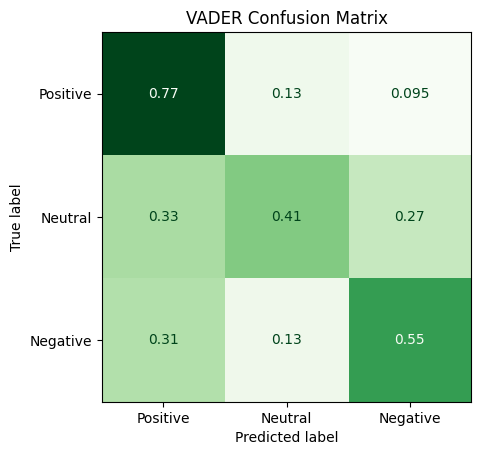

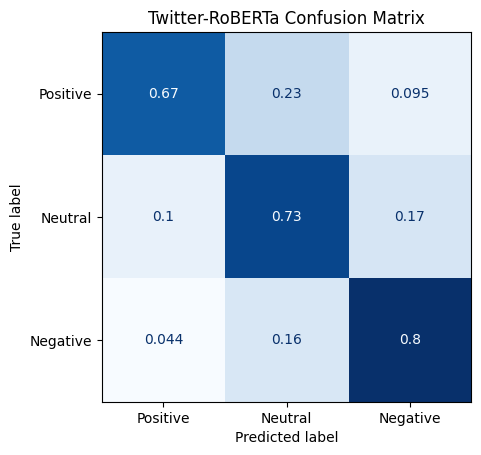

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

annotations_df['annotation_final'] = annotations_df['final_annotation']
labels=['Positive', 'Neutral', 'Negative']

CMv = confusion_matrix(annotations_df['annotation_final'].tolist(), annotations_df['vader_sentiment'].tolist(), labels = labels, normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=CMv, display_labels=labels)
display.plot(cmap=plt.cm.Greens, colorbar=False)
display.ax_.set_title("VADER Confusion Matrix")
plt.show()

CMr = confusion_matrix(annotations_df['annotation_final'].tolist(), annotations_df['roberta_sentiment'].tolist(), labels = labels, normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=CMr, display_labels=labels)
display.plot(cmap=plt.cm.Blues, colorbar=False)
display.ax_.set_title("Twitter-RoBERTa Confusion Matrix")
plt.show()

In [8]:
x = 'error'
print(vader_prediction(x, vaderAnalyzer))
vaderAnalyzer.polarity_scores(x)

Negative


{'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.4019}

In [9]:
roberta_false_negatives = annotations_df[(annotations_df['annotation_final'] != 'Positive') & (annotations_df['roberta_sentiment'] == 'Positive') & (annotations_df['vader_sentiment'] != 'Positive')]
print((roberta_false_negatives))

                                             post_text annotation_1  \
21   Ate some incredibly spicy ramen and am attempt...      Neutral   
54                                We’ve deserved that.      Neutral   
198  discarded pizza boxes are an inexpensive sourc...      Neutral   
241               That was terrifying and exhilarating     Negative   
320                                              JESUS      Neutral   
361        Every time we say... Good..BYEEEEEEE!!!!! 🎈      Neutral   
367          my clients in there will find me again 🥲🥲     Negative   
376  ope we're getting that Pharloom Docks area aft...     Positive   
534  I just... Really wanna be baby kitten again ma...      Neutral   
642                          boingggg :3,,,,,,,,,,,,,,      Neutral   
754  I’m here to make your life better or worse. Ju...      Neutral   
765  since HBO is capitalizing i put on This Is Spi...      Neutral   
766  They made waiting for godot into a musical! #T...      Neutral   
787   

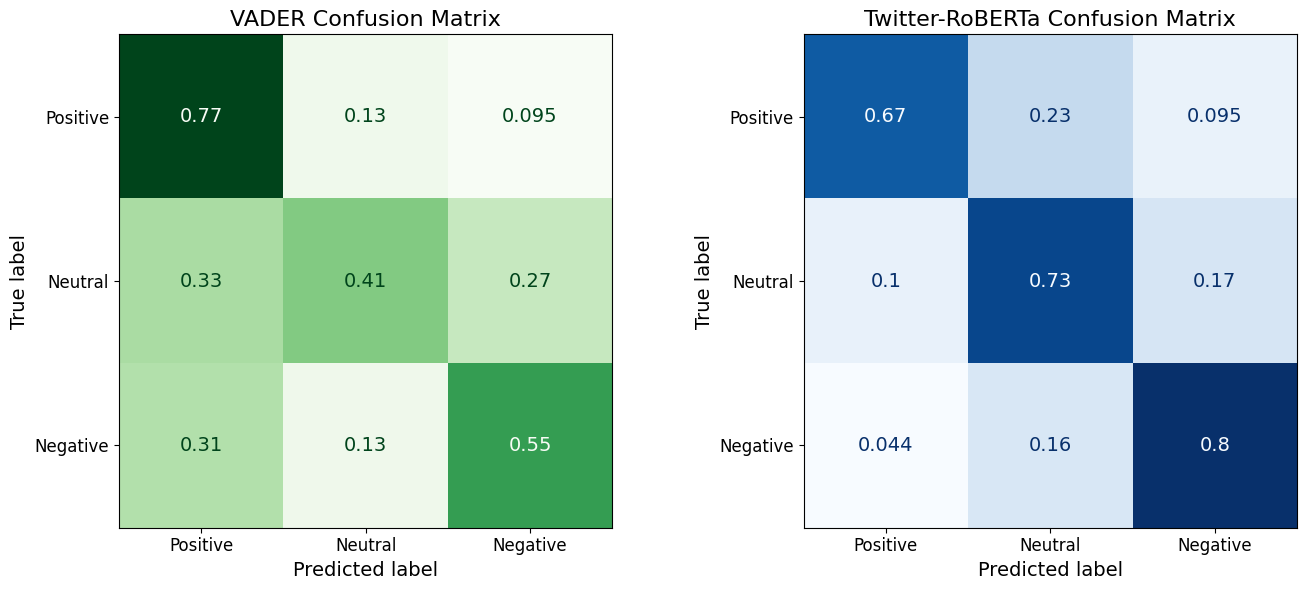

In [10]:

CMv = confusion_matrix(
    annotations_df['annotation_final'].tolist(), 
    annotations_df['vader_sentiment'].tolist(), 
    labels=labels
)

CMr = confusion_matrix(
    annotations_df['annotation_final'].tolist(), 
    annotations_df['roberta_sentiment'].tolist(), 
    labels=labels
)


CMv_norm = confusion_matrix(
    annotations_df['annotation_final'].tolist(), 
    annotations_df['vader_sentiment'].tolist(), 
    labels=labels, normalize='true'
)

CMr_norm = confusion_matrix(
    annotations_df['annotation_final'].tolist(), 
    annotations_df['roberta_sentiment'].tolist(), 
    labels=labels, normalize='true'
)


fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

disp_vader = ConfusionMatrixDisplay(confusion_matrix=CMv_norm, display_labels=labels)
disp_vader.plot(cmap=plt.cm.Greens, colorbar=False, ax=axes[0], text_kw={"fontsize": 14})
axes[0].set_title("VADER Confusion Matrix", fontsize=16)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xlabel("Predicted label", fontsize=14)
axes[0].set_ylabel("True label", fontsize=14)

disp_roberta = ConfusionMatrixDisplay(confusion_matrix=CMr_norm, display_labels=labels)
disp_roberta.plot(cmap=plt.cm.Blues, colorbar=False, ax=axes[1], text_kw={"fontsize": 14})
axes[1].set_title("Twitter-RoBERTa Confusion Matrix", fontsize=16)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlabel("Predicted label", fontsize=14)
axes[1].set_ylabel("True label", fontsize=14)

plt.tight_layout()
plt.show()

In [11]:
wrong_negatives = annotations_df[(annotations_df['annotation_final'] == 'Negative') & (annotations_df['vader_sentiment'] == 'Positive') & (annotations_df['roberta_sentiment'] == 'Negative')]
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
#print(wrong_negatives)

wrong_neutrals = annotations_df[(annotations_df['annotation_final'] == 'Neutral') & (annotations_df['vader_sentiment'] != 'Neutral')]
#print(wrong_neutrals)
print(len(wrong_negatives))
print(len(annotations_df[(annotations_df['annotation_final'] == 'Negative')]))

interesting_annotations = annotations_df.iloc[[51,53,645,698]].drop(['annotation_1', 'annotation_2', 'annotation_final'], axis=1)
print(interesting_annotations)

74
364
                                                                                                                                                                                                                                          post_text  \
51                                                                             I like sandwiches. I like gravy. I do not like gravy poured on a sandwich and social media tells me these are now the only available sandwiches in Ireland. Animals.   
53   Every stream we have to talk about AI. Every stream. But this is how I take the temperature.\n\nPer my readings, we are fried like eggs, but actual experts been telling you that. I just... These people are cool otherwise, but so ignorant.   
645                                                                                                                                                                                      had brick by ben folds five stuck in my head for two weeks   
698  

In [ ]:
print(merged_annotation_df[['post_text', 'annotation_1', 'vader_sentiment', 'roberta_sentiment']].head(20))

NameError: name 'merged_annotation_df' is not defined

: 

In [ ]:
print('Twitter-RoBERTa:')
print(CMr)
print('VADER:')
print(CMv)

Twitter-RoBERTa:
[[173  72  35]
 [ 45 270  67]
 [ 18  56 289]]
VADER:
[[198  49  33]
 [122 163  97]
 [110  58 195]]


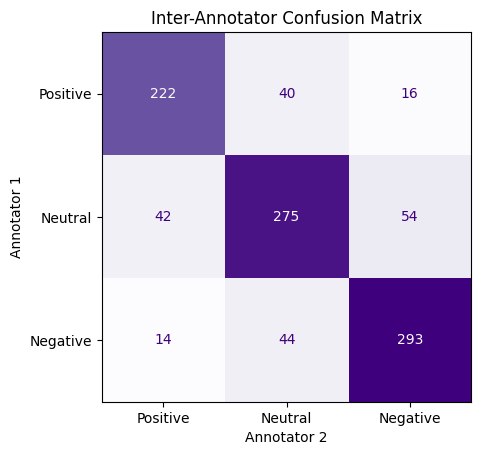

In [ ]:
kappaCM = confusion_matrix(annotations_df['annotation_1'].tolist(), annotations_df['annotation_2'].tolist(), labels=labels)

display = ConfusionMatrixDisplay(confusion_matrix=kappaCM, display_labels=labels)
display.plot(cmap=plt.cm.Purples, colorbar=False)
display.ax_.set_title("Inter-Annotator Confusion Matrix")
display.ax_.set_xlabel("Annotator 2", fontsize=10)
display.ax_.set_ylabel("Annotator 1", fontsize=10)
plt.show()